# KCE080BCT048 — Predicting Market Trends
## Pipeline Orchestration

This notebook runs the full end-to-end pipeline:

| Step | Module |
|------|--------|
| 1. Data Ingestion | `ingestion.py` |
| 2. Initial Cleaning | `cleaning.py` → `run_initial_cleaning` |
| 3. EDA + Feature Engineering | `eda.py` → `run_eda` |
| 4. Post-Feature Cleaning | `cleaning.py` → `run_post_feature_cleaning` |
| 5. Model Training & Evaluation | `model.py` → `run_model_pipeline` |

## Step 1 — Data Ingestion

In [1]:
from ingestion import load_data

df = load_data("sp500_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume,policy_change,fedrete,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,1/4/2010,1132.989990,1133.869995,1116.560059,1116.560059,3991400000,0,0.11,NaN,NaN,NaN
1,1/5/2010,1136.520020,1136.630005,1129.660034,1132.660034,2491020000,0,0.11,NaN,NaN,NaN
2,1/6/2010,1137.140015,1139.189941,1133.949951,1135.709961,4972660000,0,0.11,NaN,NaN,NaN
3,1/7/2010,1141.689941,1142.459961,1131.319946,1136.270020,5270680000,0,0.11,NaN,NaN,NaN
4,1/8/2010,1144.979980,1145.390015,1136.219971,1140.520020,4389590000,0,0.11,NaN,NaN,NaN


## Step 2 — Initial Cleaning

Strips column whitespace, drops all-null columns and duplicates, parses dates, and sets Date as the index.

In [2]:
from cleaning import run_initial_cleaning

df = run_initial_cleaning(df)
print("Shape after initial cleaning:", df.shape)

Date              object
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
policy_change      int64
fedrete          float64
dtype: object
Shape after initial cleaning: (3774, 7)


## Step 3 — EDA & Feature Engineering

Runs exploratory summaries, distribution histograms, and correlation heatmap. After feature engineering, generates **boxplots for all numeric columns** to visualise outliers (before they are capped in Step 4). Also plots market trends with moving averages.

Shape of the data: (3774, 7)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2010-01-04 to 2024-12-31
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          3774 non-null   float64
 1   High           3774 non-null   float64
 2   Low            3774 non-null   float64
 3   Open           3774 non-null   float64
 4   Volume         3774 non-null   int64  
 5   policy_change  3774 non-null   int64  
 6   fedrete        3774 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 235.9 KB

Summary Statistics:
              Close         High          Low         Open        Volume  \
count  3774.000000  3774.000000  3774.000000  3774.000000  3.774000e+03   
mean   2728.274880  2742.224616  2712.214531  2727.736940  3.939704e+09   
std    1264.990492  1271.299419  1258.193109  1264.940853  9.492100e+08   
min    1022.580017  1032.949951  1010.909973 

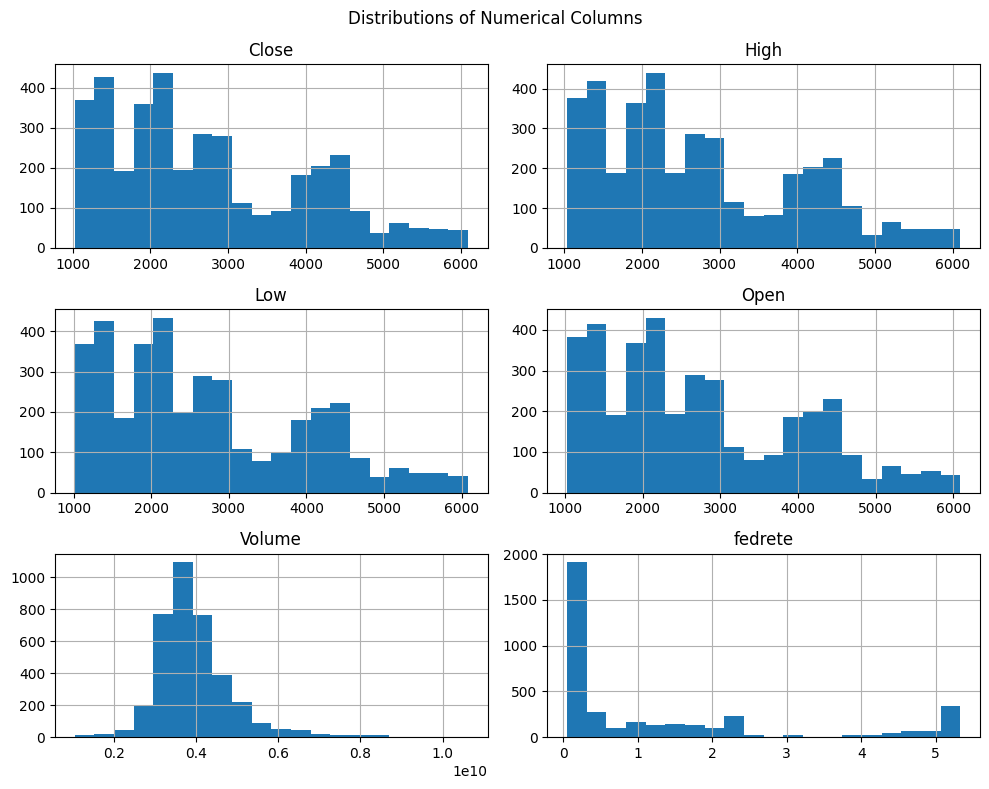

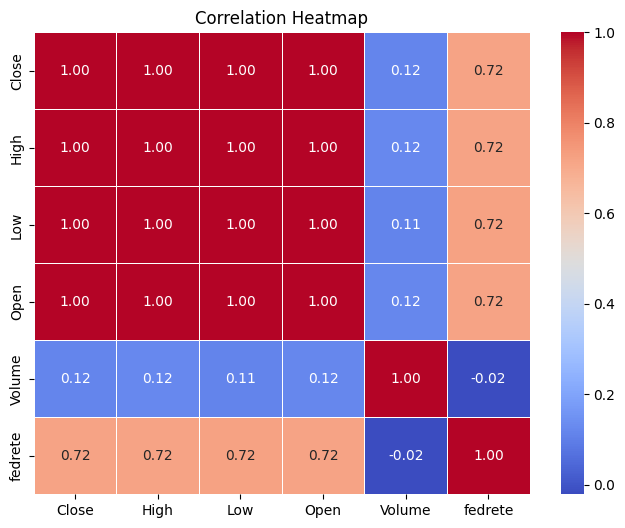

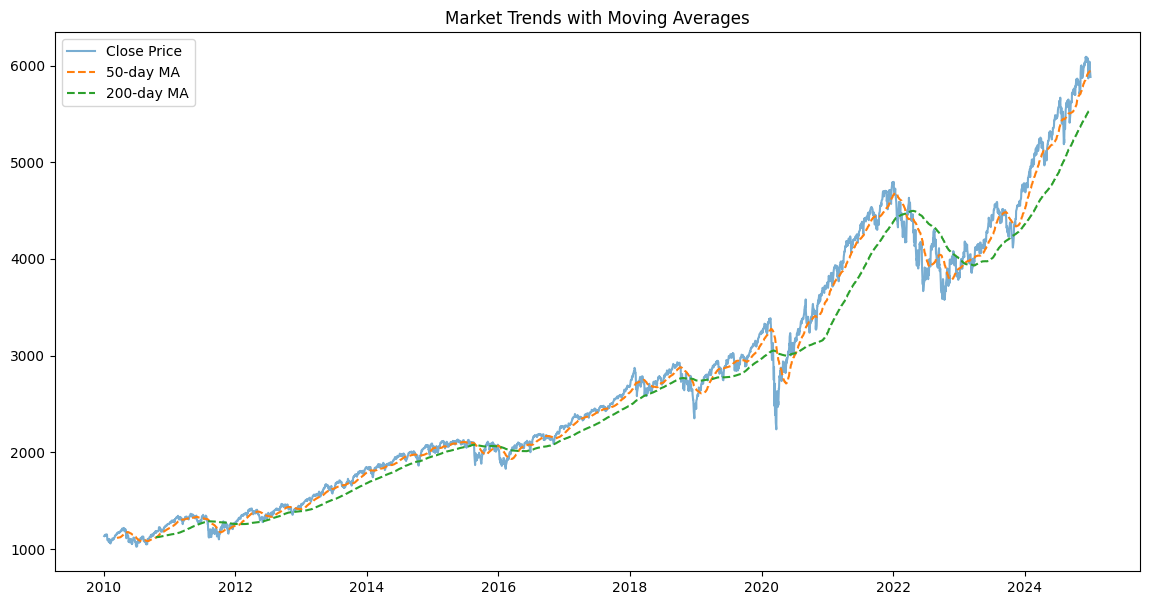

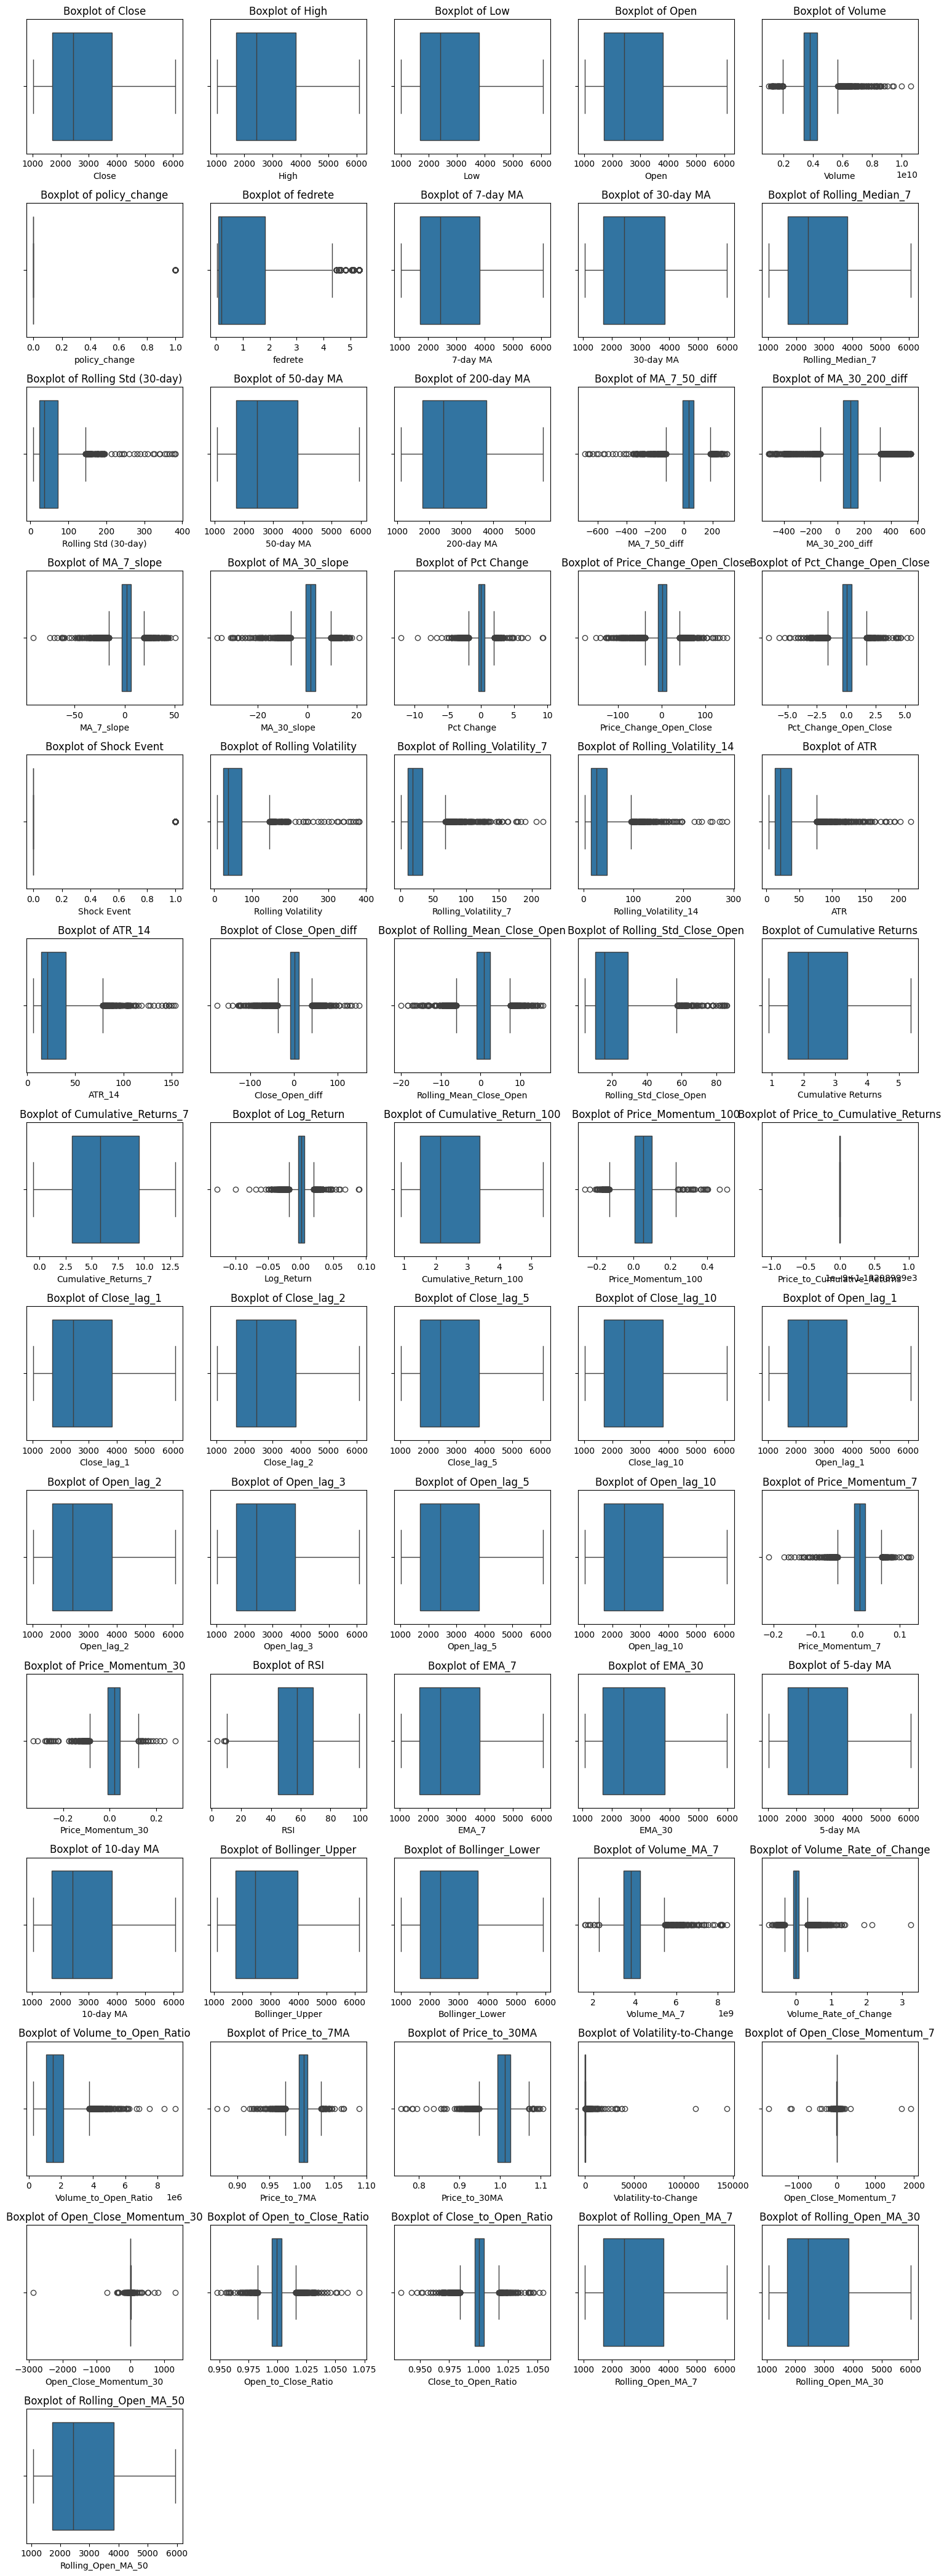

Shape after feature engineering: (3774, 70)


In [3]:
from eda import run_eda

df = run_eda(df)
print("Shape after feature engineering:", df.shape)

## Step 4 — Post-Feature Cleaning

Fills NaN values, applies log1p skewness correction, caps outliers via IQR, removes highly correlated features (|r| > 0.90), and drops any remaining inf/NaN rows.

In [4]:
from cleaning import run_post_feature_cleaning

df = run_post_feature_cleaning(df)
print("Shape after post-feature cleaning:", df.shape)
print("NaN values remaining:", df.isna().sum().sum())

Applying log1p to skewed columns: ['Volume', 'policy_change', 'fedrete', 'Rolling Std (30-day)', 'Shock Event', 'Rolling Volatility', 'Rolling_Volatility_7', 'Rolling_Volatility_14', 'ATR', 'ATR_14', 'Rolling_Std_Close_Open', 'Volume_MA_7', 'Volume_Rate_of_Change', 'Volume_to_Open_Ratio']
Remaining features after removing highly correlated ones:
['Close', 'Volume', 'policy_change', 'fedrete', 'Rolling Std (30-day)', 'Day_of_Week', 'Day_of_Month', 'Month', 'MA_7_50_diff', 'MA_30_200_diff', 'MA_7_slope', 'Pct Change', 'Price_Change_Open_Close', 'Shock Event', 'Rolling_Volatility_7', 'Rolling_Volatility_14', 'ATR', 'ATR_14', 'Rolling_Mean_Close_Open', 'Price_Momentum_100', 'RSI', 'Volume_MA_7', 'Volume_Rate_of_Change', 'Volume_to_Open_Ratio', 'Price_to_7MA', 'Price_to_30MA', 'Volatility-to-Change', 'Open_Close_Momentum_7', 'Open_Close_Momentum_30']
Shape after post-feature cleaning: (3347, 29)
NaN values remaining: 0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Step 5 — Model Training & Evaluation

Creates the target variable, splits into train/test sets, then applies **StandardScaler** (fitted only on training data to prevent leakage) and **PCA** (retaining 95% variance). Trains Random Forest / XGBoost / SVM classifiers and Random Forest / XGBoost regressors, and prints full evaluation metrics.

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Preparing targets...
Splitting, scaling, and applying shared PCA...
PCA components retained: 18 (95.596% variance)

=== Training & Evaluating Classifiers ===

Random Forest Classification Evaluation:
  Directional Accuracy: 0.7806 (78.06%)
  Precision (Up):       0.7821
  Recall (Up):          0.8905
  F1 Score:             0.8328
              precision    recall  f1-score   support

           0     0.7772    0.6062    0.6811       259
           1     0.7821    0.8905    0.8328       411

    accuracy                         0.7806       670
   macro avg     0.7796    0.7483    0.7569       670
weighted avg     0.7802    0.7806    0.7741       670



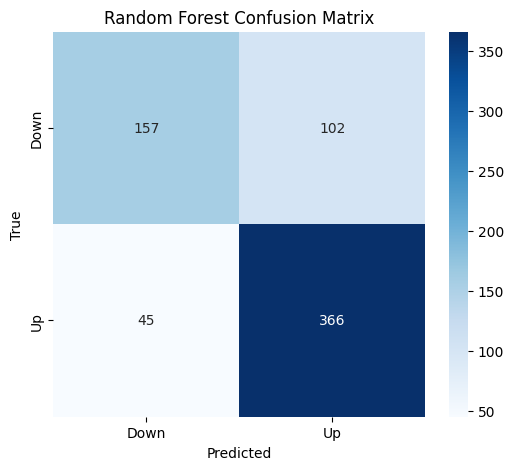


XGBoost Classification Evaluation:
  Directional Accuracy: 0.7657 (76.57%)
  Precision (Up):       0.7725
  Recall (Up):          0.8759
  F1 Score:             0.8210
              precision    recall  f1-score   support

           0     0.7500    0.5907    0.6609       259
           1     0.7725    0.8759    0.8210       411

    accuracy                         0.7657       670
   macro avg     0.7613    0.7333    0.7409       670
weighted avg     0.7638    0.7657    0.7591       670



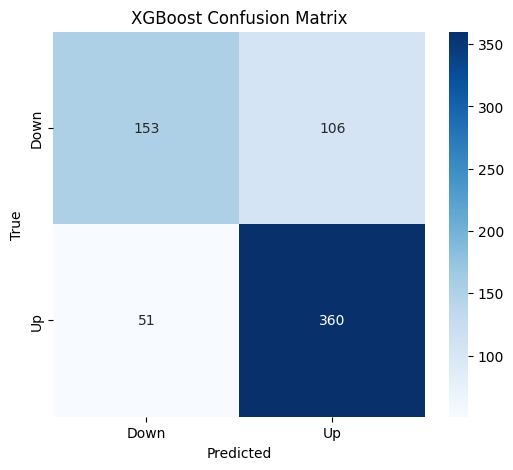


SVM Classification Evaluation:
  Directional Accuracy: 0.8418 (84.18%)
  Precision (Up):       0.8622
  Recall (Up):          0.8832
  F1 Score:             0.8726
              precision    recall  f1-score   support

           0     0.8072    0.7761    0.7913       259
           1     0.8622    0.8832    0.8726       411

    accuracy                         0.8418       670
   macro avg     0.8347    0.8296    0.8320       670
weighted avg     0.8410    0.8418    0.8412       670



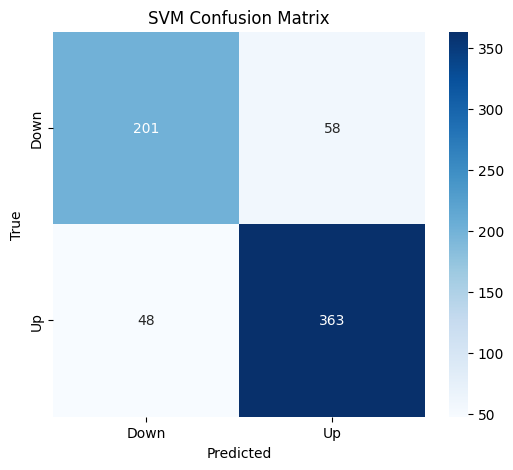


=== Training & Evaluating Regressors ===

Random Forest Regressor Regression Evaluation:
  MSE            : 0.015349
  MAE            : 0.089503
  RMSE           : 0.123893
  R²             : 0.9305
  Directional Acc: 1.0000 (100.00%)

XGBoost Regressor Regression Evaluation:
  MSE            : 0.013653
  MAE            : 0.087479
  RMSE           : 0.116846
  R²             : 0.9382
  Directional Acc: 1.0000 (100.00%)


In [5]:
from model import run_model_pipeline

classifiers, rf_reg, xgb_reg, splits = run_model_pipeline(df)

## Hyperparameter Tuning

Run this cell to perform GridSearchCV-based hyperparameter tuning for regressors and classifiers. This may take a significant amount of time.

In [ ]:
import importlib
import model
importlib.reload(model)

from model import tune_regressors, tune_classifiers, evaluate_regression, evaluate_classifiers

# ────────────────────────────────────────────────
# 1. Tune regressors -> use RAW features (not PCA, not scaled)
#    This is usually better for tree-based models like RF & XGBoost
# ────────────────────────────────────────────────
print("=== Hyperparameter tuning: Regressors (on raw features) ===")

best_rf_reg, best_xgb_reg = tune_regressors(
    splits["X_train"],          # <- raw pandas DataFrame
    splits["y_train_reg"]
)

# Evaluate tuned regressors on raw test set
evaluate_regression(best_rf_reg, splits["X_test"], splits["y_test_reg"], "Tuned RF Regressor (raw features)")
evaluate_regression(best_xgb_reg, splits["X_test"], splits["y_test_reg"], "Tuned XGBoost Regressor (raw features)")


# ────────────────────────────────────────────────
# 2. Tune classifiers -> use PCA-transformed features
#    (this is what the default classifiers were trained on)
# ────────────────────────────────────────────────
print("\n=== Hyperparameter tuning: Classifiers (on PCA features) ===")

best_rf_clf, best_xgb_clf, best_svm_clf = tune_classifiers(
    splits["X_train_pca"],      # <- PCA numpy array
    splits["y_train_clf"]
)

# Collect tuned models for evaluation
tuned_models = {
    "RF (tuned)": best_rf_clf,
    "XGBoost (tuned)": best_xgb_clf,
    "SVM (tuned)": best_svm_clf
}

# Evaluate tuned classifiers
evaluate_classifiers(tuned_models, splits["X_test_pca"], splits["y_test_clf"])


# Optional: also show quick comparison with default models
print("\nQuick comparison - default vs tuned classifiers")
default_classifiers = {
    "RF (default)": classifiers["Random Forest"],
    "XGBoost (default)": classifiers["XGBoost"],
    "SVM (default)": classifiers["SVM"]
}
evaluate_classifiers(default_classifiers, splits["X_test_pca"], splits["y_test_clf"])

=== Hyperparameter tuning: Regressors (on raw features) ===
Tuning regressors...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best RandomForestRegressor params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV neg MSE: -0.003425163920150178


AttributeError: 'super' object has no attribute '__sklearn_tags__'

Predictions

In [ ]:
import pandas as pd
import numpy as np
import joblib

# ────────────────────────────────────────────────
# A. Prepare ONE new data point (tomorrow's features)
# ────────────────────────────────────────────────

# Example: you manually create or fetch today's features
# (must have exactly the same columns as X_train)
today_data = {
    'Volume': 4200000000,
    'fedrete': 4.25,
    'Day_of_Week': 1,           # 0 = Monday, 4 = Friday, etc.
    'Day_of_Month': 13,
    'Month': 3,
    'Rolling Std (30-day)': 45.2,
    # ... add ALL other features your model was trained on
    # You can get the exact list from:
    # print(splits["X_train"].columns.tolist())
}

new_df = pd.DataFrame([today_data])

# ────────────────────────────────────────────────
# B. Apply same preprocessing (VERY IMPORTANT!)
# ────────────────────────────────────────────────

# Load saved scaler & PCA (created during training)
scaler = joblib.load("scaler.pkl")
pca    = joblib.load("pca.pkl")

# Scale → PCA transform
new_scaled = scaler.transform(new_df)
new_pca    = pca.transform(new_scaled)

# ────────────────────────────────────────────────
# C. Predict with chosen model
# ────────────────────────────────────────────────

# Option A: Use one of the tuned regressors (price level)
predicted_close = best_xgb_reg.predict(new_pca)[0]
print(f"Predicted next Close price: {predicted_close:,.2f}")

# Option B: Use classifier (up/down probability)
up_probability = best_svm_clf.predict_proba(new_pca)[0][1]   # probability of class 1 = Up
direction = "Up" if up_probability > 0.5 else "Down"
print(f"Predicted direction: {direction} (confidence: {up_probability:.1%})")

In [ ]:
import pandas as pd
import numpy as np

# Assume you have a new DataFrame new_data with many rows
# (same columns as original X). If not provided, use test features as a demo.
if "new_data" not in globals():
    new_data = splits["X_test"].copy()
    print("new_data not found; using splits['X_test'] as demo input.")

# 1. Preprocess exactly the same way
new_scaled = splits["scaler"].transform(new_data)   # or joblib.load("scaler.pkl")
new_pca    = splits["pca"].transform(new_scaled)    # or joblib.load("pca.pkl")

# 2. Predict with best models
reg_preds = best_xgb_reg.predict(new_pca)           # price levels
clf_preds = best_svm_clf.predict(new_pca)           # 0 = down, 1 = up
clf_probas = best_svm_clf.predict_proba(new_pca)[:, 1]  # probability of Up

# 3. Create nice output table
results = pd.DataFrame({
    'Predicted_Close': reg_preds,
    'Predicted_Direction': np.where(clf_preds == 1, 'Up', 'Down'),
    'Up_Probability': clf_probas.round(3)
}, index=new_data.index)

print(results.tail(10))   # last 10 predictions

Real-time / daily prediction function

In [ ]:
def predict_tomorrow(model_reg, model_clf, today_features_df):
    """
    Single function to get both price forecast and direction probability.
    
    today_features_df : pd.DataFrame with 1 row and correct columns
    """
    if not isinstance(today_features_df, pd.DataFrame):
        today_features_df = pd.DataFrame([today_features_df])
    
    scaler = joblib.load("scaler.pkl")
    pca    = joblib.load("pca.pkl")
    
    scaled = scaler.transform(today_features_df)
    pca_features = pca.transform(scaled)
    
    pred_price = model_reg.predict(pca_features)[0]
    prob_up    = model_clf.predict_proba(pca_features)[0][1]
    direction  = "↑ Up" if prob_up >= 0.5 else "↓ Down"
    
    return {
        "predicted_close": round(pred_price, 2),
        "direction": direction,
        "up_probability": round(prob_up * 100, 1),
        "confidence": "High" if abs(prob_up - 0.5) > 0.25 else "Medium/Low"
    }


# Example usage
tomorrow_forecast = predict_tomorrow(
    best_xgb_reg,
    best_svm_clf,           # or best_rf_clf, etc.
    today_data              # dict or 1-row DataFrame
)

print("Tomorrow's S&P 500 forecast:")
print(f"Predicted Close: {tomorrow_forecast['predicted_close']:,.2f}")
print(f"Expected move:   {tomorrow_forecast['direction']}")
print(f"Up probability:  {tomorrow_forecast['up_probability']}%")
print(f"Confidence:      {tomorrow_forecast['confidence']}")